<a href="https://colab.research.google.com/github/Subash65/App/blob/main/Zeotap_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Customers.csv to Customers (1).csv
Saving Products.csv to Products (1).csv
Saving Transactions.csv to Transactions (1).csv


In [ ]:
customers = pd.read_csv("Customers.csv")
products = pd.read_csv("Products.csv")
transactions = pd.read_csv("Transactions.csv")

In [ ]:
print("Customers Data:\n", customers.head())
print("\nProducts Data:\n", products.head())
print("\nTransactions Data:\n", transactions.head())

Customers Data:
   CustomerID        CustomerName         Region  SignupDate
0      C0001    Lawrence Carroll  South America  2022-07-10
1      C0002      Elizabeth Lutz           Asia  2022-02-13
2      C0003      Michael Rivera  South America  2024-03-07
3      C0004  Kathleen Rodriguez  South America  2022-10-09
4      C0005         Laura Weber           Asia  2022-08-15

Products Data:
   ProductID              ProductName     Category   Price
0      P001     ActiveWear Biography        Books  169.30
1      P002    ActiveWear Smartwatch  Electronics  346.30
2      P003  ComfortLiving Biography        Books   44.12
3      P004            BookWorld Rug   Home Decor   95.69
4      P005          TechPro T-Shirt     Clothing  429.31

Transactions Data:
   TransactionID CustomerID ProductID      TransactionDate  Quantity  \
0        T00001      C0199      P067  2024-08-25 12:38:23         1   
1        T00112      C0146      P067  2024-05-27 22:23:54         1   
2        T00166      C01

In [ ]:
print("\nCustomers Info:")
customers.info()
print("\nProducts Info:")
products.info()
print("\nTransactions Info:")
transactions.info()


Customers Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    200 non-null    object
 1   CustomerName  200 non-null    object
 2   Region        200 non-null    object
 3   SignupDate    200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB

Products Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ProductID    100 non-null    object 
 1   ProductName  100 non-null    object 
 2   Category     100 non-null    object 
 3   Price        100 non-null    float64
dtypes: float64(1), object(3)
memory usage: 3.3+ KB

Transactions Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  D

In [ ]:
print("\nMissing Values:")
print("Customers:\n", customers.isnull().sum())
print("Products:\n", products.isnull().sum())
print("Transactions:\n", transactions.isnull().sum())


Missing Values:
Customers:
 CustomerID      0
CustomerName    0
Region          0
SignupDate      0
dtype: int64
Products:
 ProductID      0
ProductName    0
Category       0
Price          0
dtype: int64
Transactions:
 TransactionID      0
CustomerID         0
ProductID          0
TransactionDate    0
Quantity           0
TotalValue         0
Price              0
dtype: int64


In [ ]:
customers.fillna(method='ffill', inplace=True)
products.fillna(method='ffill', inplace=True)
transactions.fillna(method='ffill', inplace=True)

<ipython-input-7-f231d23b54e8>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  customers.fillna(method='ffill', inplace=True)
<ipython-input-7-f231d23b54e8>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  products.fillna(method='ffill', inplace=True)
<ipython-input-7-f231d23b54e8>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  transactions.fillna(method='ffill', inplace=True)


In [ ]:
customers['SignupDate'] = pd.to_datetime(customers['SignupDate'])
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])

In [ ]:
merged_df = transactions.merge(customers, on="CustomerID").merge(products, on="ProductID")

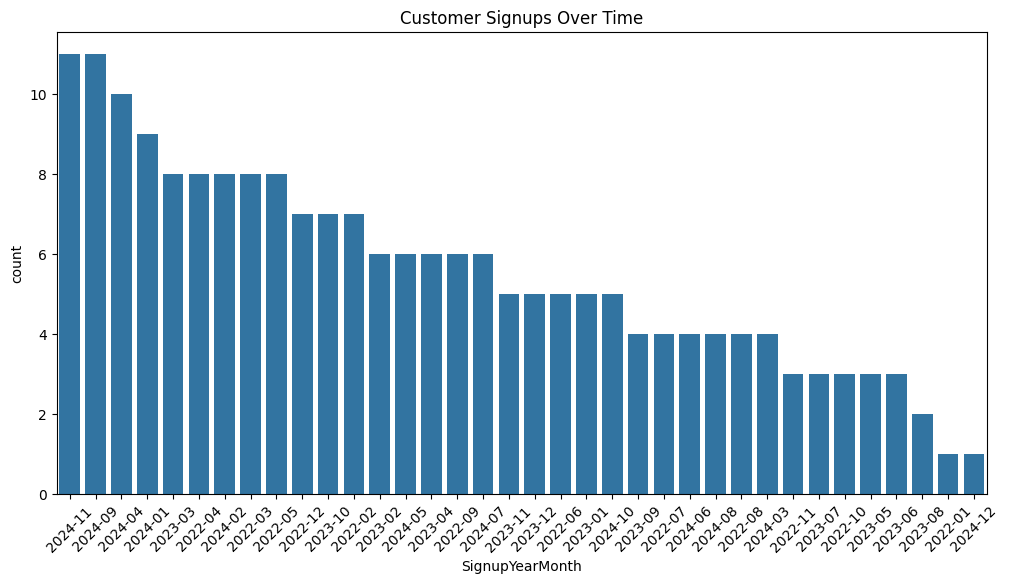

In [ ]:
## 1. Customer Signup Trends
customers['SignupYearMonth'] = customers['SignupDate'].dt.to_period('M')
plt.figure(figsize=(12, 6))
sns.countplot(data=customers, x='SignupYearMonth', order=customers['SignupYearMonth'].value_counts().index)
plt.title('Customer Signups Over Time')
plt.xticks(rotation=45)
plt.show()

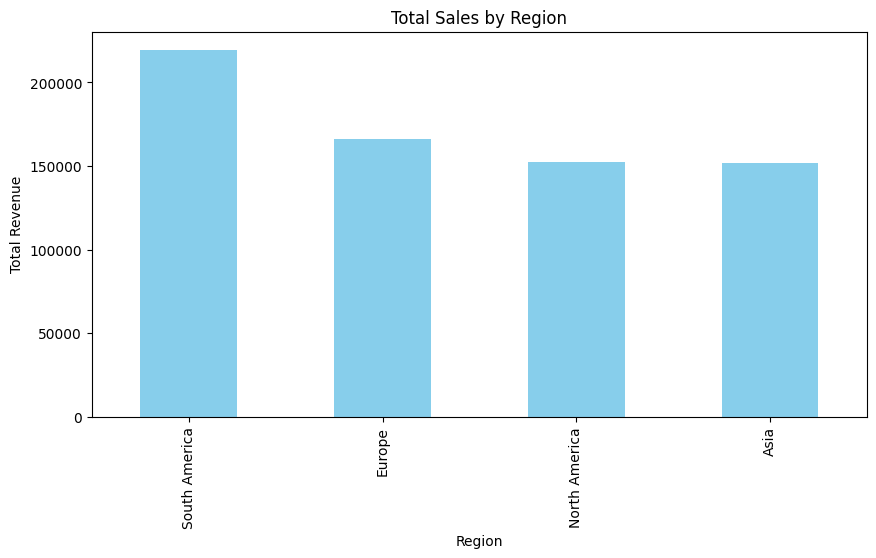

In [ ]:
sales_by_region = merged_df.groupby('Region')['TotalValue'].sum().sort_values(ascending=False)
sales_by_region.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Total Sales by Region')
plt.ylabel('Total Revenue')
plt.show()

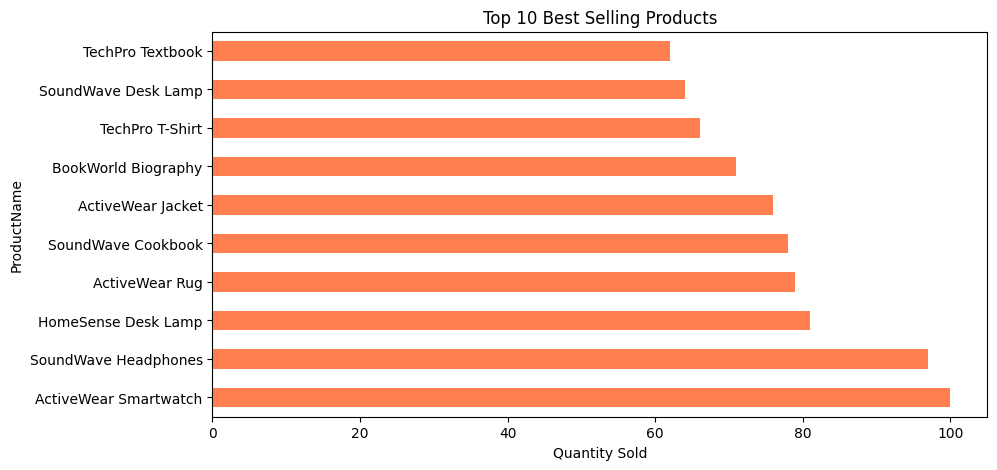

In [ ]:
## 3. Top Selling Products
top_products = merged_df.groupby('ProductName')['Quantity'].sum().nlargest(10)
top_products.plot(kind='barh', figsize=(10, 5), color='coral')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Quantity Sold')
plt.show()

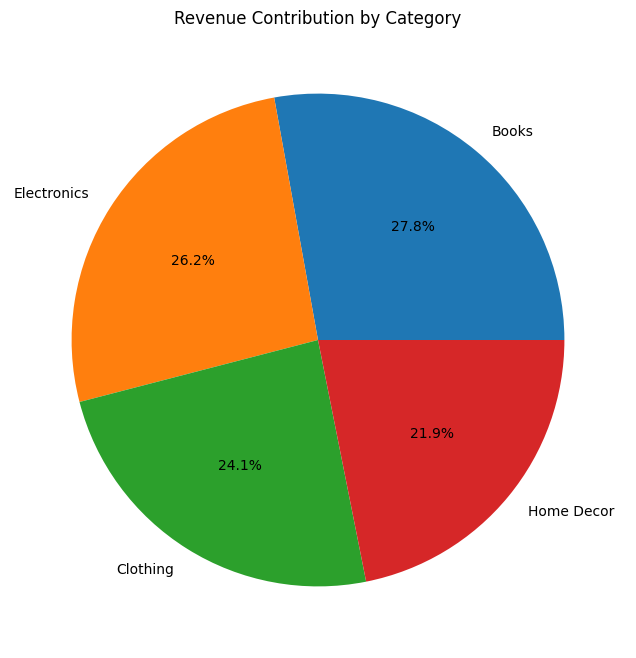

In [ ]:
## 4. Revenue Contribution by Product Category
category_revenue = merged_df.groupby('Category')['TotalValue'].sum().sort_values(ascending=False)
category_revenue.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Revenue Contribution by Category')
plt.ylabel('')
plt.show()

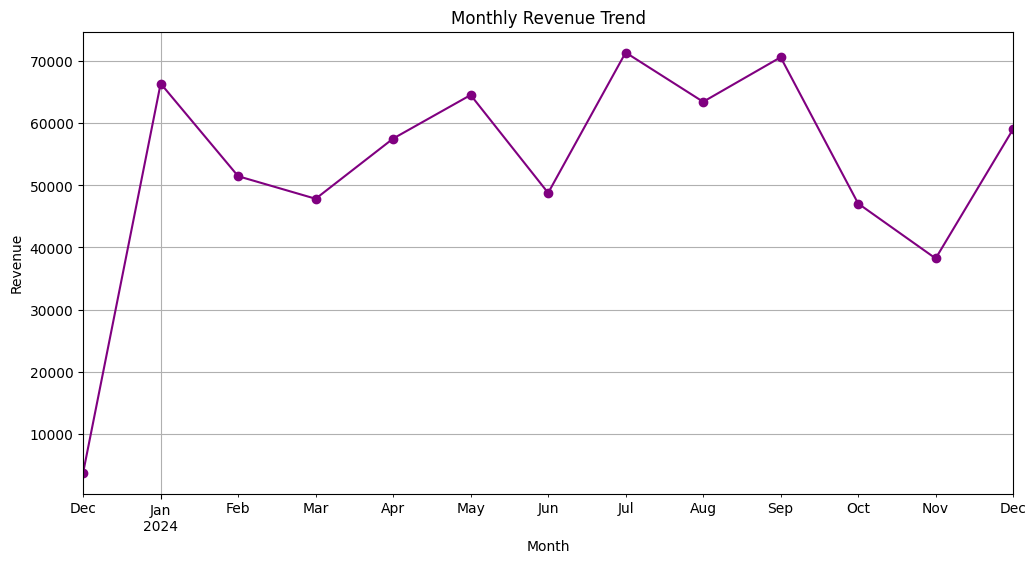

In [ ]:
## Monthly Revenue Trend
merged_df['TransactionMonth'] = merged_df['TransactionDate'].dt.to_period('M')
monthly_revenue = merged_df.groupby('TransactionMonth')['TotalValue'].sum()
plt.figure(figsize=(12, 6))
monthly_revenue.plot(marker='o', color='purple')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid()
plt.show()

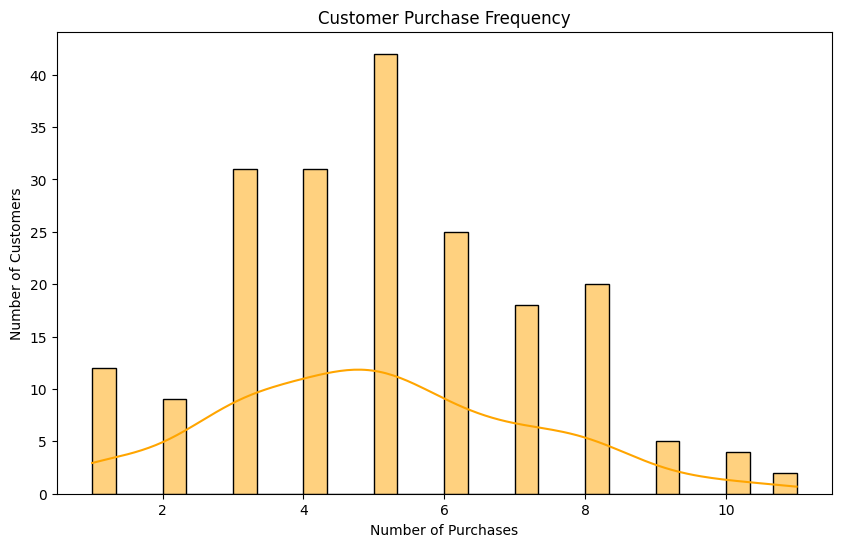

In [ ]:
## 7. Customer Purchase Frequency Distribution
plt.figure(figsize=(10, 6))
purchase_counts = merged_df['CustomerID'].value_counts()
sns.histplot(purchase_counts, bins=30, kde=True, color='orange')
plt.title('Customer Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

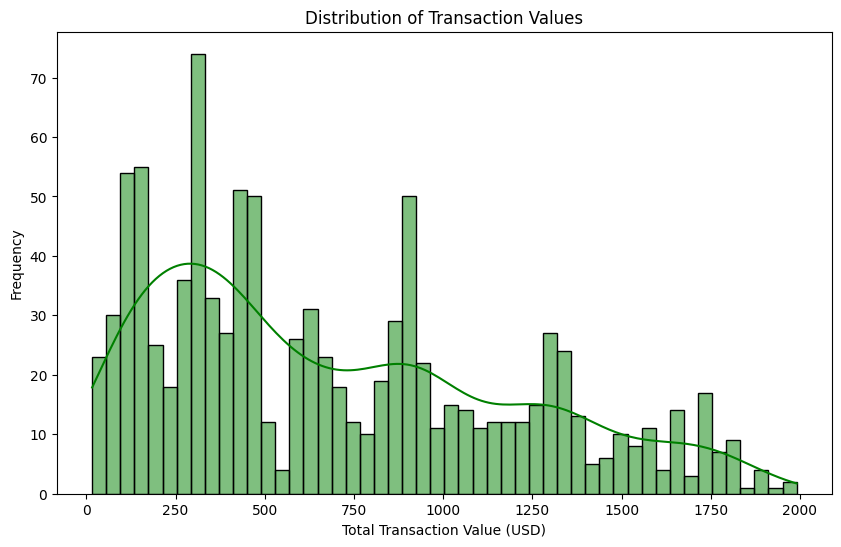

In [ ]:
## 8. Distribution of Transaction Values
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['TotalValue'], bins=50, kde=True, color='green')
plt.title('Distribution of Transaction Values')
plt.xlabel('Total Transaction Value (USD)')
plt.ylabel('Frequency')
plt.show()

<Figure size 1200x800 with 0 Axes>

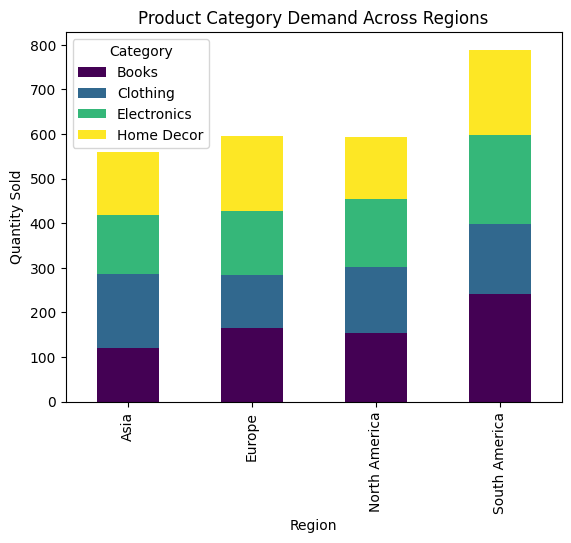

In [ ]:
## 9. Product Category Demand Across Regions
plt.figure(figsize=(12, 8))
category_region = merged_df.groupby(['Region', 'Category'])['Quantity'].sum().unstack()
category_region.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Product Category Demand Across Regions')
plt.xlabel('Region')
plt.ylabel('Quantity Sold')
plt.legend(title='Category')
plt.show()



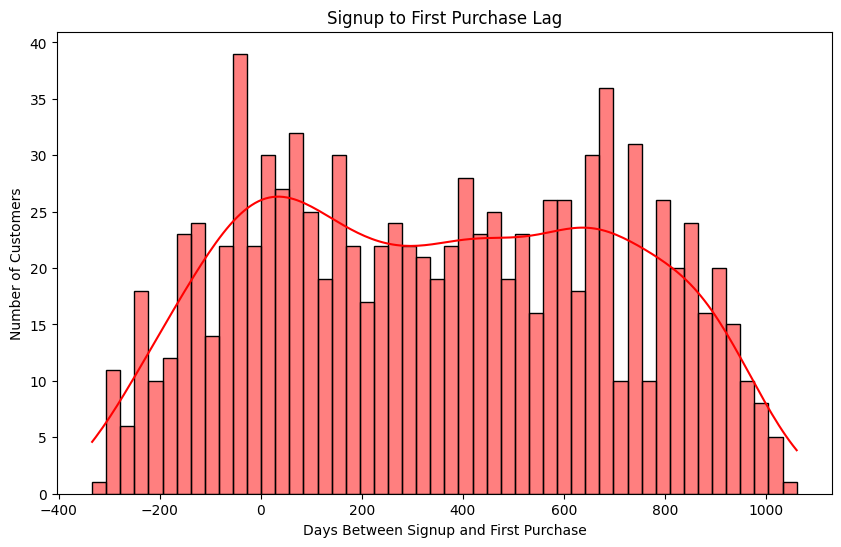

In [ ]:
## 10. Customer Signup vs. First Purchase Lag
merged_df['SignupToPurchaseDays'] = (merged_df['TransactionDate'] - merged_df['SignupDate']).dt.days
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['SignupToPurchaseDays'], bins=50, kde=True, color='red')
plt.title('Signup to First Purchase Lag')
plt.xlabel('Days Between Signup and First Purchase')
plt.ylabel('Number of Customers')
plt.show()